In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
from ydata_profiling import ProfileReport

#metrics
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

C:\Users\Tanvir Ishrak\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('bangladesh_student_performance.csv')
df

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,29/04/2018,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57,3.18
2014,29/04/2018,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05,3.13
2015,29/04/2018,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93,3.15
2016,29/04/2018,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34,2.83


In [3]:
profile = ProfileReport(df , title="Bangladesh student performance prediction", explorative=True)
profile.to_file('ydata.html')

Export report to file: 100%|████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 129.29it/s]


In [36]:
# simplify
df.columns

#ydata_profiling often switches matplotlib to a non-interactive backend (Agg),
#which prevents plots from displaying in Jupyter. The code runs, but nothing shows.
%matplotlib inline


In [5]:
if 'date' in df.columns:
    df.drop(columns=['date'], inplace=True)
    
df.columns

Index(['gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu', 'F_Edu',
       'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [6]:
df.columns

Index(['gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu', 'F_Edu',
       'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [7]:
# correlations for numerical vals
corr_target = df.select_dtypes(include=np.number ).corr()['hsc_result'].sort_values(ascending=False)
corr_target


hsc_result      1.000000
ssc_result      0.950178
M_Edu           0.063776
F_Edu           0.054811
tuition_fee     0.038068
age            -0.009857
time_friends   -0.156356
Name: hsc_result, dtype: float64

In [8]:
# separate x and y
x=df.drop('hsc_result', axis=1)
y=df['hsc_result']


In [9]:
numeric_features = x.select_dtypes(include = ['int64','float64']).columns
categorical_features = x.select_dtypes(include = ['object']).columns

In [10]:
# Pipeline for numerical 
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
# Pipeline for categorical
cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

#combine them
preprocessor = ColumnTransformer(
    transformers= [
        ('num',num_transformer,numeric_features),
        ('cat',cat_transformer,categorical_features)
    ]
    )

In [11]:
x_train , x_test, y_train , y_test=train_test_split(
    x,y, test_size=0.2 , random_state=42
)

In [12]:
# base learner
reg_lr = LinearRegression()
reg_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
reg_gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)


In [13]:
# voting regressor
voting_reg = VotingRegressor(
    estimators=[
        ('lr', reg_lr),
        ('rf',reg_rf),
        ('gb', reg_gb)
    ]
)


In [14]:
# stacking
stacking_reg = StackingRegressor(
    estimators=[
        ('rf',reg_rf),
        ('gb', reg_gb)
    ],
    final_estimator=Ridge() # meta learner
)

In [15]:
# model training
#dictionary of all model
model_to_train ={
    'Linear Regression' : reg_lr,
    'Random Forest':reg_rf,
    'GradientBoosting Regressor':reg_gb,
    'Voting ensemle':voting_reg,
    'Stacking ensemble':stacking_reg
}

In [16]:
# training and evaluation 
result = []

for name,model in model_to_train.items():
    # creat fill pipeline with preprocessor
    pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('model',model)
        ]
    )

    # train
    pipe.fit(x_train , y_train)

    #predict
    y_pred = pipe.predict(x_test)

    #evalueate
    r2 = r2_score(y_test , y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mse = mean_absolute_error(y_test,y_pred)


    result.append({
        'Model':name,
        'R2 score':r2,
        'RMSE':rmse,
        'MSE':mse
    })

results_df = pd.DataFrame(result).sort_values('R2 score', ascending=False)
print(results_df)

                        Model  R2 score      RMSE       MSE
4           Stacking ensemble  0.959566  0.123105  0.098696
2  GradientBoosting Regressor  0.959565  0.123107  0.098902
3              Voting ensemle  0.957528  0.126169  0.100838
1               Random Forest  0.950248  0.136556  0.108201
0           Linear Regression  0.945920  0.142371  0.111376


In [31]:
# visualization
best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]
best_model_obj


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as th

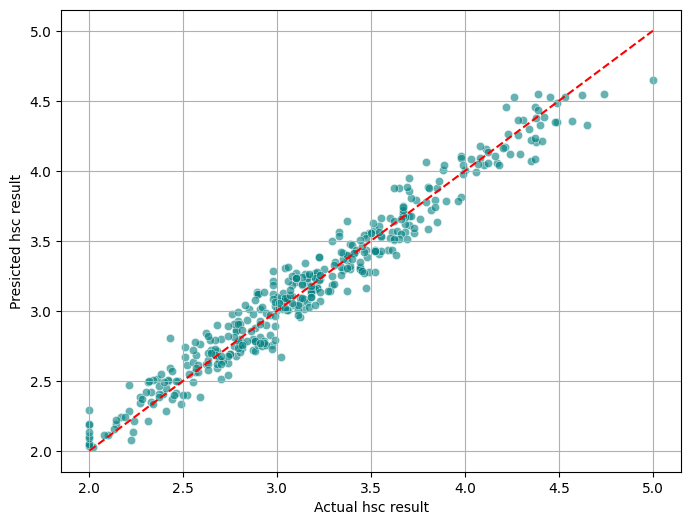

In [35]:
#fit the best model
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',best_model_obj)
])

final_pipe.fit(x_train,y_train)
y_final_pred = final_pipe.predict(x_test)

# plot actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test , y=y_final_pred , alpha=0.6 , color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel('Actual hsc result')
plt.ylabel('Presicted hsc result')
plt.grid(True)
plt.show()
